# Worst-cell diagnostics analysis

This notebook-style script inspects the 10 worst held-out cells identified by
the revision-round diagnostics for both SOH and RUL. It augments the error
ranking with cycle-life and protocol metadata and compares those properties
against the training-cell population.

In [8]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.experiments.protocol_robustness import build_protocol_families

## Load datasets and manifests

In [9]:
repo_root = Path().absolute().parent.parent
features_path = repo_root / "data" / "interim" / "features.parquet"
artifact_root = (
    repo_root / "results" / "results" / "experiments" / "revision_round1"
)
manifest_path = artifact_root / "manifest.json"

features_df = pd.read_parquet(features_path)
manifest = json.loads(manifest_path.read_text())

sns.set_theme(style="whitegrid", context="talk")

In [10]:
def resolve_run(
    track: str,
    target: str,
    feature_set_id: str | None = None,
) -> Path:
    runs = [
        run
        for run in manifest["runs"]
        if run["track"] == track and run["target"] == target
    ]
    if feature_set_id is not None:
        runs = [
            run for run in runs if run.get("feature_set_id") == feature_set_id
        ]
    if len(runs) != 1:
        raise ValueError(
            f"Expected exactly one run for {track=}, {target=}, "
            f"{feature_set_id=}, found {len(runs)}."
        )
    return artifact_root / runs[0]["run_dir"]


def empirical_percentile(reference: pd.Series, value: float) -> float:
    ref = reference.astype(float).dropna()
    if ref.empty:
        return float("nan")
    return float((ref <= float(value)).mean() * 100.0)


def load_diagnostics_top10(target: str) -> pd.DataFrame:
    run_dir = resolve_run("diagnostics", target, feature_set_id="full_all")
    diag_df = pd.read_csv(run_dir / "diagnostics.cells.csv")
    diag_df["is_difficult_cell"] = (
        diag_df["is_difficult_cell"].astype(str).str.lower() == "true"
    )
    return (
        diag_df[diag_df["is_difficult_cell"]]
        .sort_values("rmse", ascending=False)
        .head(10)
        .copy()
    )

## Build cell-level metadata

In [11]:
split_manifest = json.loads(
    (
        resolve_run("final_eval", "SOH", feature_set_id="full_all")
        / "split.manifest.json"
    ).read_text()
)
train_cells = split_manifest["train_cells"]
test_cells = split_manifest["test_cells"]

family_df = build_protocol_families(
    features_df=features_df,
    cells_rated_capacity=1.1,
    max_c_rate_bins=4,
    min_cells_per_family=6,
)

cell_meta_df = (
    features_df.groupby("cell", as_index=False)
    .agg(
        cycle_life=("cycle", "max"),
        charge_policy=("charge_policy", "first"),
    )
    .merge(
        family_df[
            [
                "cell",
                "avg_charge_c_rate",
                "max_charge_c_rate",
                "max_c_rate_bin",
                "protocol_family",
            ]
        ],
        on="cell",
        how="left",
    )
)
cell_meta_df["split"] = "train"
cell_meta_df.loc[cell_meta_df["cell"].isin(test_cells), "split"] = "test"

train_meta_df = cell_meta_df[cell_meta_df["split"] == "train"].copy()
test_meta_df = cell_meta_df[cell_meta_df["split"] == "test"].copy()

print(f"Train cells: {train_meta_df['cell'].nunique()}")
print(f"Test cells: {test_meta_df['cell'].nunique()}")
cell_meta_df.head()

Train cells: 99
Test cells: 25


,cell,cycle_life,charge_policy,avg_charge_c_rate,max_charge_c_rate,max_c_rate_bin,protocol_family,split
0,b1c0,1806,3.6C(80%)-3.6C,1.828126,2.211618,0,bin_0__no_rest,test
1,b1c1,2158,3.6C(80%)-3.6C,1.837783,2.712438,2,bin_2__no_rest,train
2,b1c11,786,5.4C(50%)-3C,2.068944,2.507892,1,bin_1__no_rest,train
3,b1c14,878,5.4C(60%)-3C,2.174432,2.568733,1,bin_1__no_rest,train
4,b1c15,717,5.4C(60%)-3C,2.129277,2.468870,0,bin_0__no_rest,test


## Build worst-cell tables enriched with protocol information

In [12]:
worst_frames = []
for target in ["SOH", "RUL"]:
    top10_df = load_diagnostics_top10(target)
    enriched_df = top10_df.merge(cell_meta_df, on="cell", how="left")
    enriched_df["target"] = target
    enriched_df["train_cells_same_family"] = enriched_df["protocol_family"].map(
        train_meta_df.groupby("protocol_family")["cell"].nunique()
    )
    enriched_df["train_cells_same_policy"] = enriched_df["charge_policy"].map(
        train_meta_df.groupby("charge_policy")["cell"].nunique()
    )
    enriched_df["cycle_life_train_percentile"] = enriched_df["cycle_life"].map(
        lambda value: empirical_percentile(train_meta_df["cycle_life"], value)
    )
    enriched_df["max_c_rate_train_percentile"] = enriched_df[
        "max_charge_c_rate"
    ].map(
        lambda value: empirical_percentile(
            train_meta_df["max_charge_c_rate"], value
        )
    )
    worst_frames.append(enriched_df)

worst_cells_df = pd.concat(worst_frames, ignore_index=True)

summary_cols = [
    "target",
    "cell",
    "rmse",
    "mae",
    "dominant_error_region",
    "cycle_life",
    "protocol_family",
    "max_charge_c_rate",
    "charge_policy",
    "train_cells_same_family",
    "train_cells_same_policy",
    "cycle_life_train_percentile",
    "max_c_rate_train_percentile",
]
worst_cells_df[summary_cols].sort_values(["target", "rmse"], ascending=[True, False])

,target,cell,rmse,mae,dominant_error_region,cycle_life,protocol_family,max_charge_c_rate,charge_policy,train_cells_same_family,train_cells_same_policy,cycle_life_train_percentile,max_c_rate_train_percentile
10,RUL,b3c7,368.432597,317.886069,early_life,1834,bin_2__no_rest,2.919643,4.8C(80%)-4.8C-newstructure,23,3.0,96.969697,59.595960
11,RUL,b1c3,210.182225,173.643183,mid_life,1432,bin_0__no_rest,2.414948,4C(80%)-4C,24,1.0,93.939394,14.141414
12,RUL,b2c1,163.115294,145.139514,early_life,146,bin_2__no_rest,2.787290,2C(10%)-6C,23,NaN,0.000000,53.535354
13,RUL,b1c0,155.959067,123.341000,mid_life,1806,bin_0__no_rest,2.211618,3.6C(80%)-3.6C,24,2.0,96.969697,0.000000
14,RUL,b3c25,110.886302,83.664919,early_life,987,bin_2__no_rest,2.927209,5.3C(54%)-4C-newstructure,23,6.0,76.767677,60.606061
15,RUL,b3c39,101.688073,87.170564,mid_life,1154,bin_2__no_rest,3.040130,5.3C(54%)-4C-newstructure,23,6.0,90.909091,73.737374
16,RUL,b1c36,98.217202,81.356270,mid_life,702,bin_0__no_rest,2.413694,7C(40%)-3C,24,NaN,44.444444,14.141414
17,RUL,b3c8,83.551845,70.816177,early_life,826,bin_2__no_rest,2.957045,5C(67%)-4C-newstructure,23,5.0,60.606061,65.656566
18,RUL,b1c37,78.255257,61.711685,early_life,646,bin_0__no_rest,2.405709,7C(40%)-3C,24,NaN,39.393939,14.141414
19,RUL,b1c40,75.290191,56.719034,early_life,964,bin_2__no_rest,2.997067,8C(15%)-3.6C,23,1.0,76.767677,67.676768


## Compact per-target summaries

In [13]:
for target in ["SOH", "RUL"]:
    print("\n" + "=" * 80)
    print(target)
    display_df = worst_cells_df.loc[
        worst_cells_df["target"] == target,
        [
            "cell",
            "rmse",
            "mae",
            "cycle_life",
            "dominant_error_region",
            "protocol_family",
            "max_charge_c_rate",
            "train_cells_same_family",
            "train_cells_same_policy",
        ],
    ].sort_values("rmse", ascending=False)
    print(display_df.to_string(index=False))


SOH
 cell     rmse      mae  cycle_life dominant_error_region protocol_family  max_charge_c_rate  train_cells_same_family  train_cells_same_policy
b1c20 1.596276 1.295059         532             late_life  bin_1__no_rest           2.651497                       26                      NaN
 b1c0 1.594413 1.227494        1806             late_life  bin_0__no_rest           2.211618                       24                      2.0
 b2c1 1.543896 1.333524         146             late_life  bin_2__no_rest           2.787290                       23                      NaN
 b3c7 1.412001 1.265818        1834              mid_life  bin_2__no_rest           2.919643                       23                      3.0
b2c42 1.401841 1.131866         464             late_life  bin_3__no_rest           3.047630                       26                      NaN
 b1c3 1.285257 0.870604        1432             late_life  bin_0__no_rest           2.414948                       24                    

## How represented are the worst cells in the training population?

In [14]:
representation_df = (
    worst_cells_df.groupby(["target", "protocol_family"], as_index=False)
    .agg(
        n_worst_cells=("cell", "nunique"),
        mean_rmse=("rmse", "mean"),
        mean_cycle_life=("cycle_life", "mean"),
        train_cells_same_family=("train_cells_same_family", "first"),
    )
    .sort_values(["target", "protocol_family"])
)
representation_df 

,target,protocol_family,n_worst_cells,mean_rmse,mean_cycle_life,train_cells_same_family
0,RUL,bin_0__no_rest,4,135.653438,1146.500000,24
1,RUL,bin_2__no_rest,6,150.494050,985.166667,23
2,SOH,bin_0__no_rest,2,1.439835,1619.000000,24
3,SOH,bin_1__no_rest,2,1.356680,513.000000,26
4,SOH,bin_2__no_rest,4,1.347075,932.750000,23
5,SOH,bin_3__no_rest,2,1.231173,462.000000,26


## Plot 1: cycle life vs. max charge C-rate

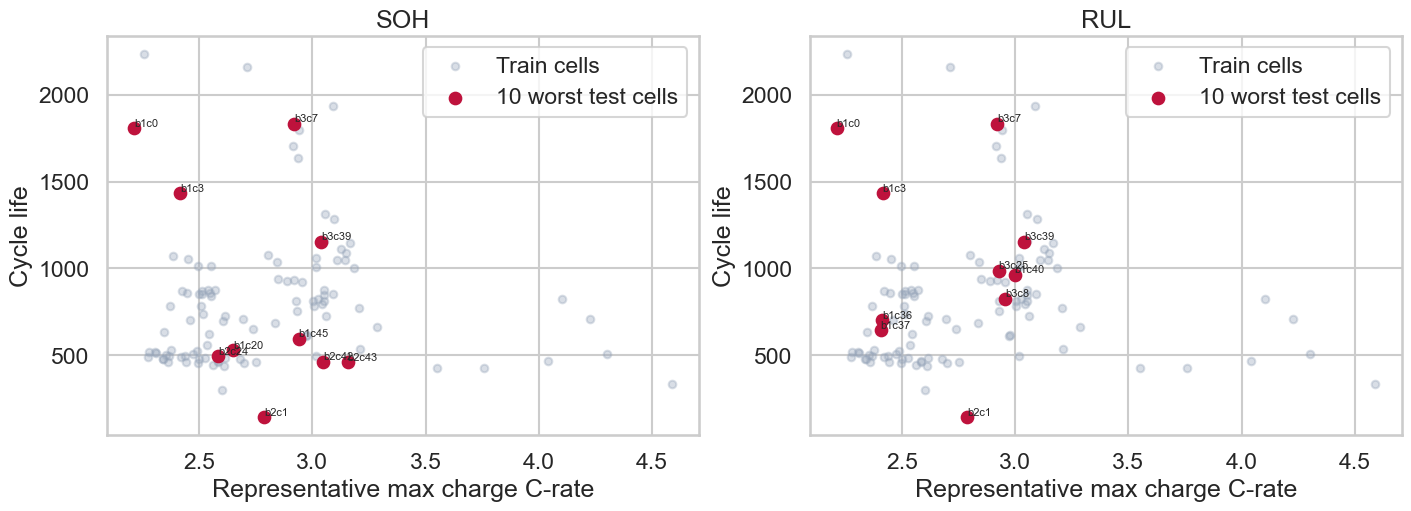

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, target in zip(axes, ["SOH", "RUL"]):
    target_worst_df = worst_cells_df[worst_cells_df["target"] == target]
    ax.scatter(
        train_meta_df["max_charge_c_rate"],
        train_meta_df["cycle_life"],
        s=30,
        alpha=0.35,
        color="#94a3b8",
        label="Train cells",
    )
    ax.scatter(
        target_worst_df["max_charge_c_rate"],
        target_worst_df["cycle_life"],
        s=70,
        color="#be123c",
        label="10 worst test cells",
    )
    for _, row in target_worst_df.iterrows():
        ax.text(
            row["max_charge_c_rate"],
            row["cycle_life"],
            row["cell"],
            fontsize=8,
            ha="left",
            va="bottom",
        )
    ax.set_title(target)
    ax.set_xlabel("Representative max charge C-rate")
    ax.set_ylabel("Cycle life")
    ax.legend(frameon=True)
plt.show()

## Plot 2: cycle-life distribution against the training population

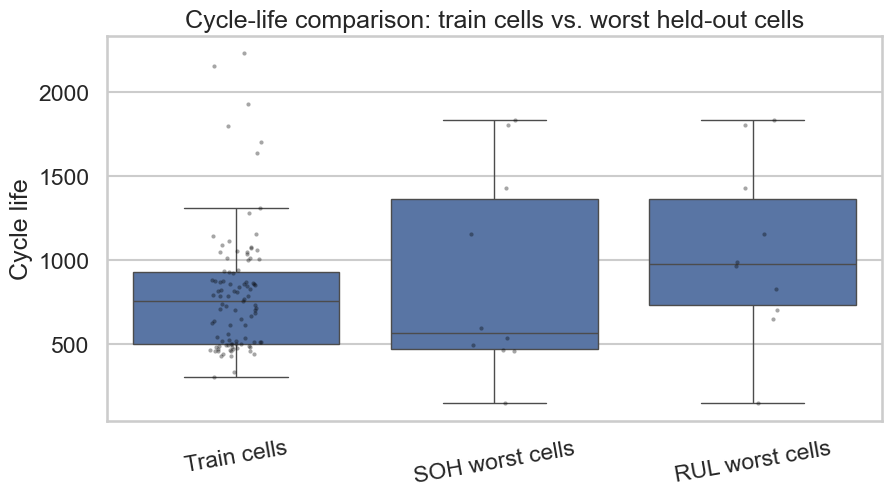

In [16]:
comparison_rows = []
for target in ["SOH", "RUL"]:
    target_worst_df = worst_cells_df[worst_cells_df["target"] == target].copy()
    target_worst_df["group"] = f"{target} worst cells"
    comparison_rows.append(
        target_worst_df[["cycle_life", "group"]].rename(
            columns={"cycle_life": "value"}
        )
    )

train_cycle_df = train_meta_df[["cycle_life"]].copy()
train_cycle_df["group"] = "Train cells"
comparison_rows.insert(
    0, train_cycle_df.rename(columns={"cycle_life": "value"})
)

cycle_compare_df = pd.concat(comparison_rows, ignore_index=True)

plt.figure(figsize=(10, 5))
sns.boxplot(data=cycle_compare_df, x="group", y="value", fliersize=0)
sns.stripplot(data=cycle_compare_df, x="group", y="value", color="black", alpha=0.35, size=3)
plt.xlabel("")
plt.ylabel("Cycle life")
plt.title("Cycle-life comparison: train cells vs. worst held-out cells")
plt.xticks(rotation=10)
plt.show()

## Plot 3: protocol-family composition

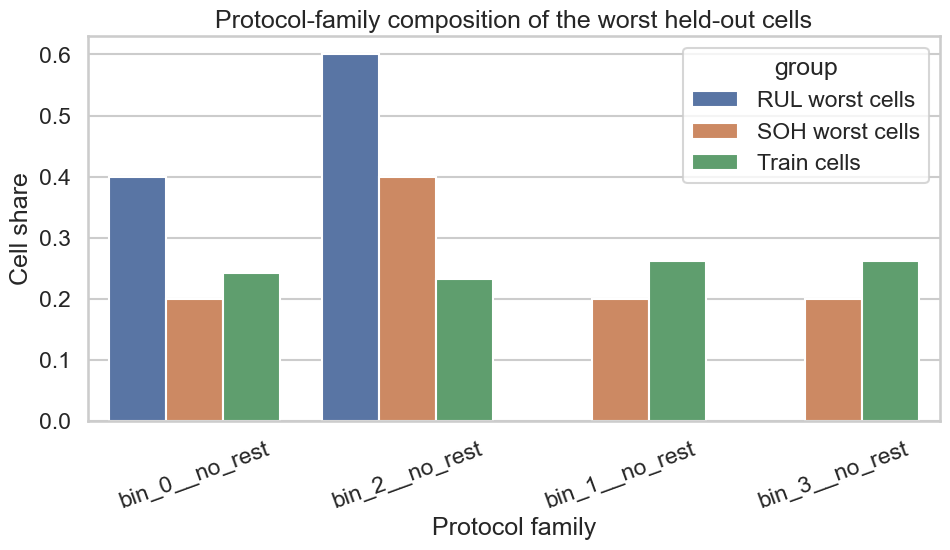

In [17]:
family_rows = [
    train_meta_df.assign(group="Train cells")[["protocol_family", "group"]],
]
for target in ["SOH", "RUL"]:
    family_rows.append(
        worst_cells_df.loc[
            worst_cells_df["target"] == target,
            ["protocol_family"],
        ].assign(group=f"{target} worst cells")
    )
family_compare_df = pd.concat(family_rows, ignore_index=True)

family_share_df = (
    family_compare_df.groupby(["group", "protocol_family"], as_index=False)
    .size()
    .rename(columns={"size": "n_cells"})
)
family_share_df["share"] = family_share_df.groupby("group")["n_cells"].transform(
    lambda s: s / s.sum()
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=family_share_df,
    x="protocol_family",
    y="share",
    hue="group",
)
plt.xlabel("Protocol family")
plt.ylabel("Cell share")
plt.title("Protocol-family composition of the worst held-out cells")
plt.xticks(rotation=20)
plt.show()